In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.datasets import load_wine
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin


### Regresja i regularyzacja (zbiór WINE)

In [45]:
data = load_wine()
X = data.data
X = pd.DataFrame(X, columns=data.feature_names)

In [54]:
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [42]:
X.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

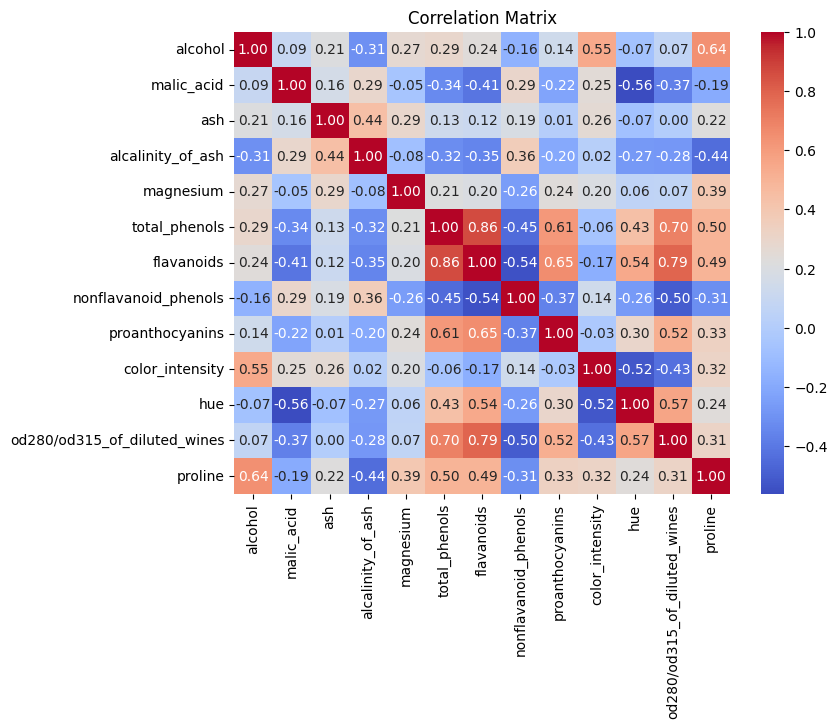

In [43]:
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

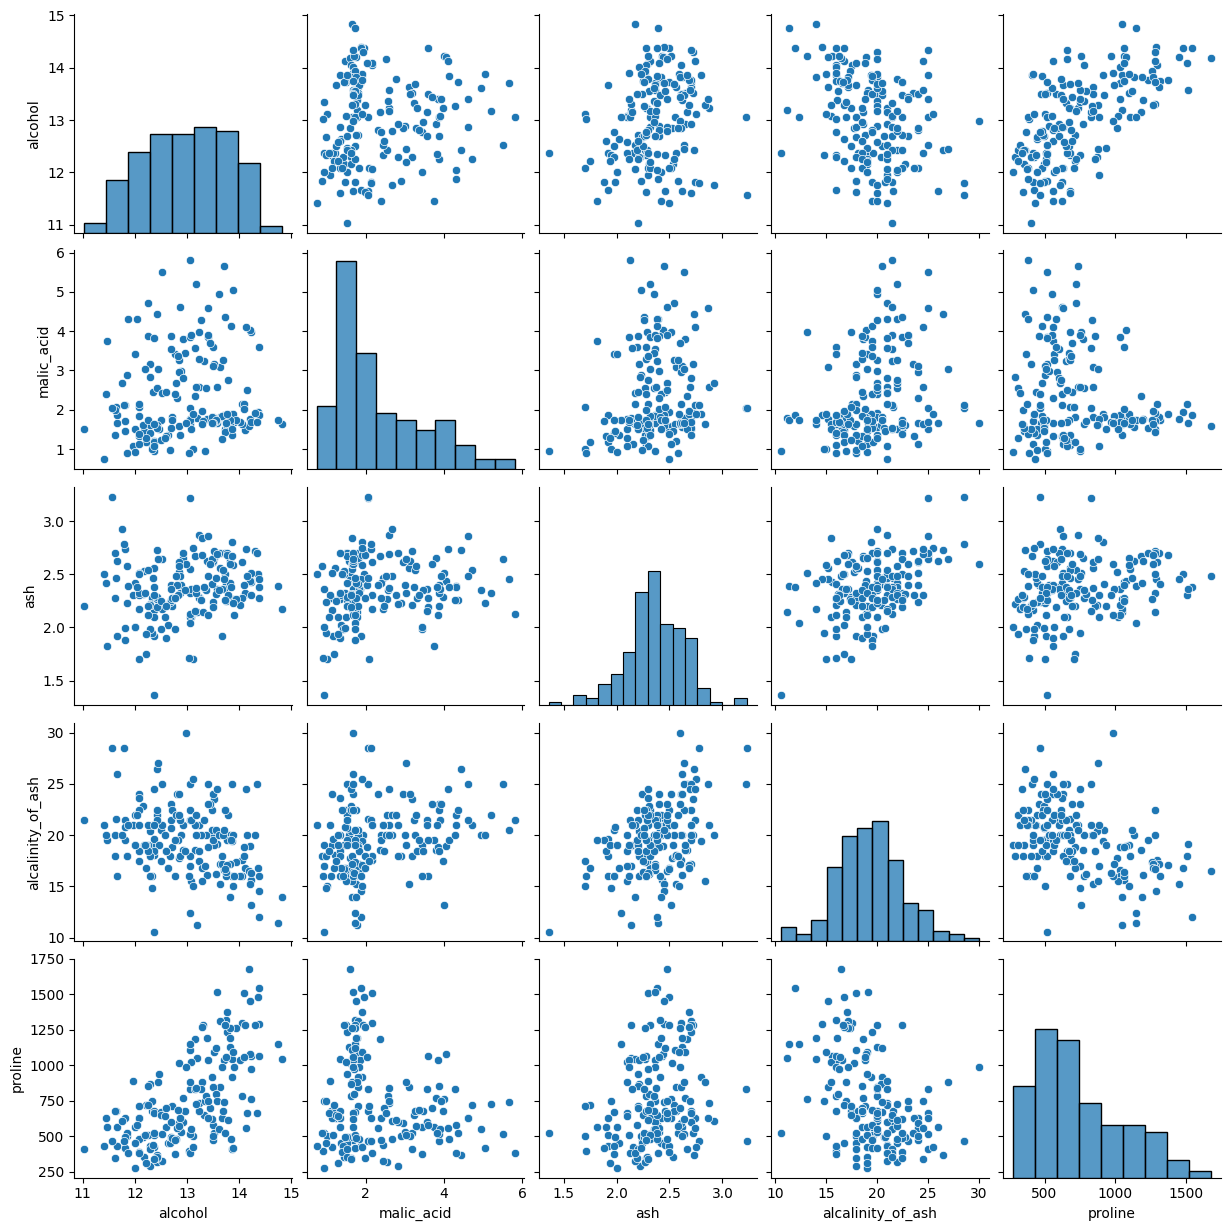

In [52]:
sns.pairplot(X[["alcohol", "malic_acid", "ash", "alcalinity_of_ash", "proline"]])

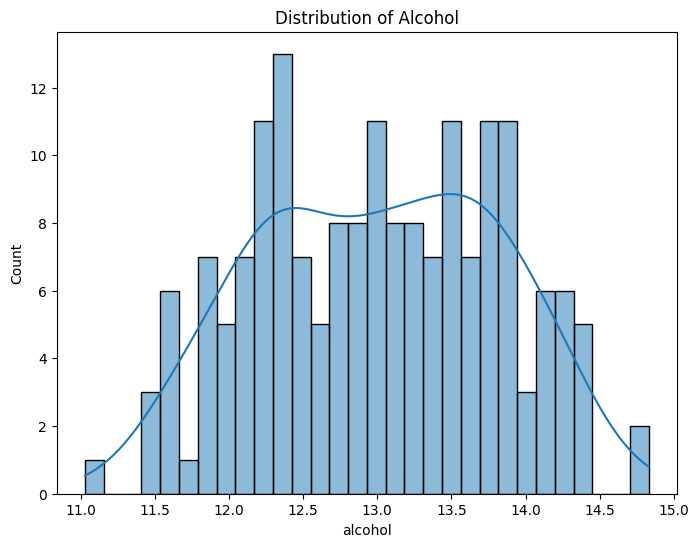

In [47]:
plt.figure(figsize=(8, 6))
sns.histplot(X["alcohol"], bins=30, kde=True)

plt.title("Distribution of Alcohol")
plt.show()

In [44]:
y = X["alcohol"]
X = X.drop(columns=["alcohol"])

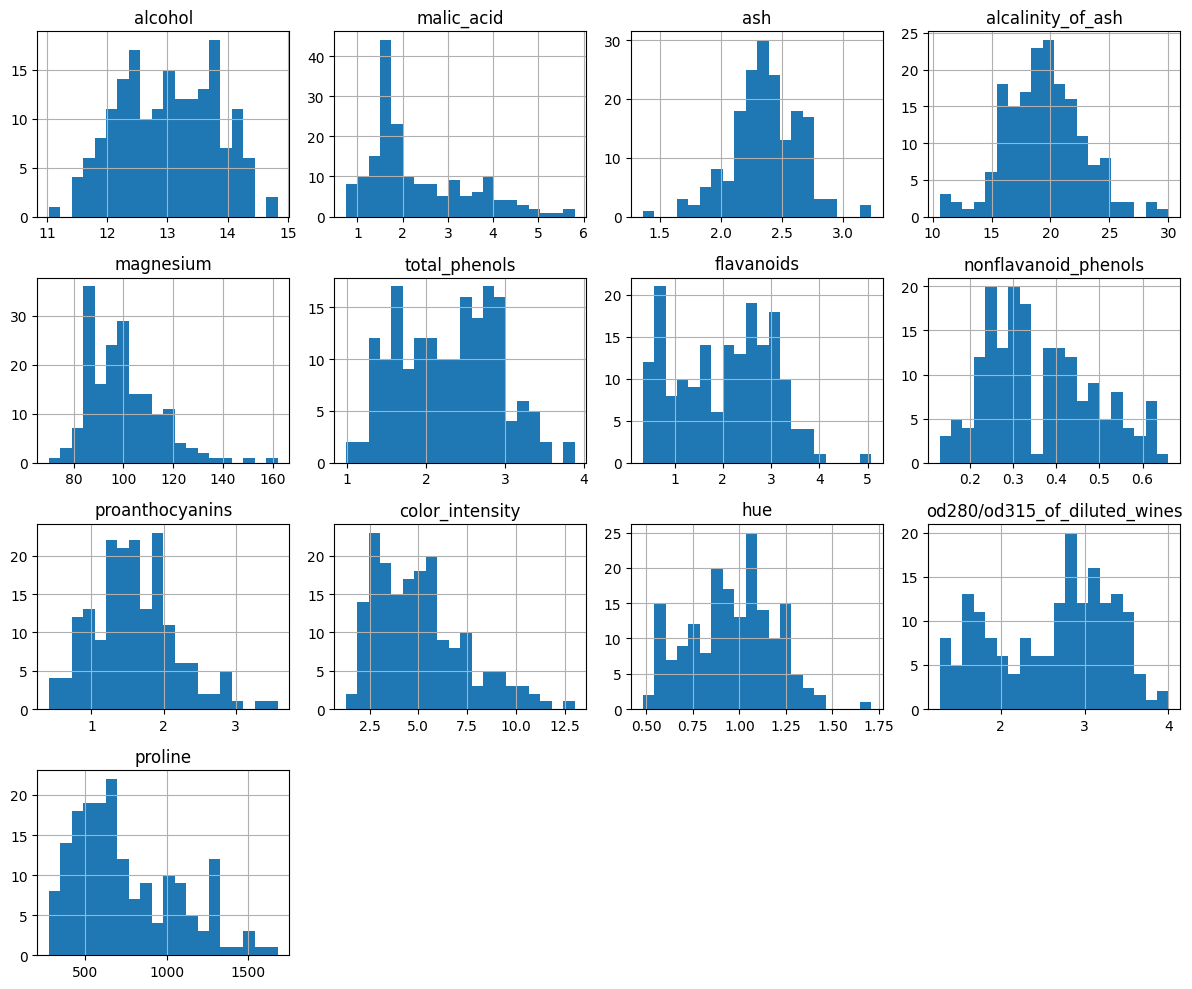

In [53]:
X.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

___

In [56]:
regression_pipeline = Pipeline(
    [("scaler", StandardScaler()), ("regressor", LinearRegression())]
)

regression_pipeline.fit(X_train, y_train)
y_pred = regression_pipeline.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

y_pred_train = regression_pipeline.predict(X_train)
train_mse = mean_squared_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

print(f"Train MSE: {train_mse:.2f}, Train R²: {train_r2:.2f}")
print(f"Test MSE: {test_mse:.2f}, Test R²: {test_r2:.2f}")

Train MSE: 0.30, Train R²: 0.58
Test MSE: 0.15, Test R²: 0.64


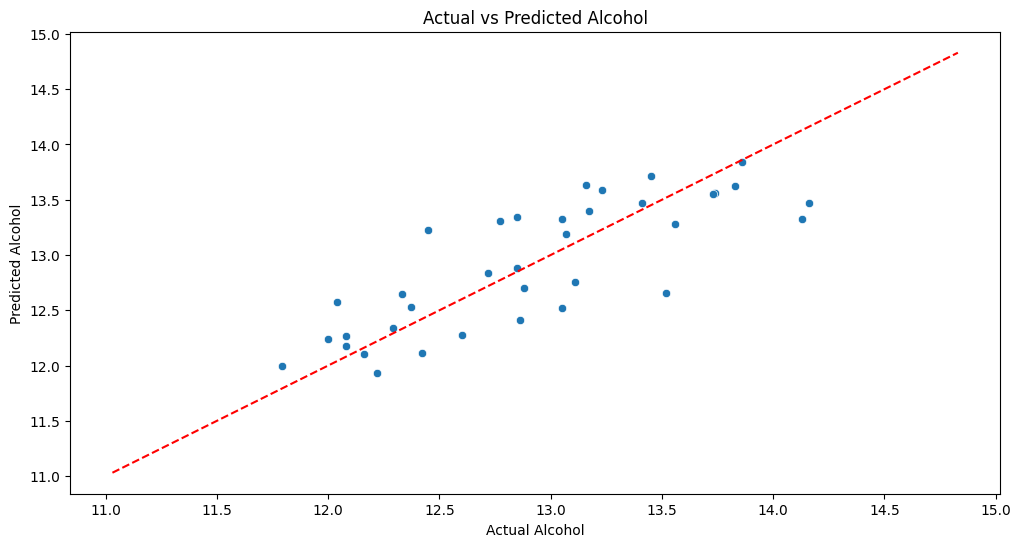

In [62]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Actual Alcohol")
plt.ylabel("Predicted Alcohol")
plt.title("Actual vs Predicted Alcohol")
plt.show()

___

In [67]:
ridge_pipeline_generator = lambda alpha: Pipeline(
    [("scaler", StandardScaler()), ("regressor", Ridge(alpha=alpha))]
)

lasso_pipeline_generator = lambda alpha: Pipeline(
    [("scaler", StandardScaler()), ("regressor", Lasso(alpha=alpha))]
)

In [68]:
alphas = np.logspace(-2, 4, 100)

ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    ridge_model = ridge_pipeline_generator(alpha)
    ridge_model.fit(X_train, y_train)
    ridge_coefs.append(ridge_model.named_steps["regressor"].coef_)

    lasso_model = lasso_pipeline_generator(alpha)
    lasso_model.fit(X_train, y_train)
    lasso_coefs.append(lasso_model.named_steps["regressor"].coef_)

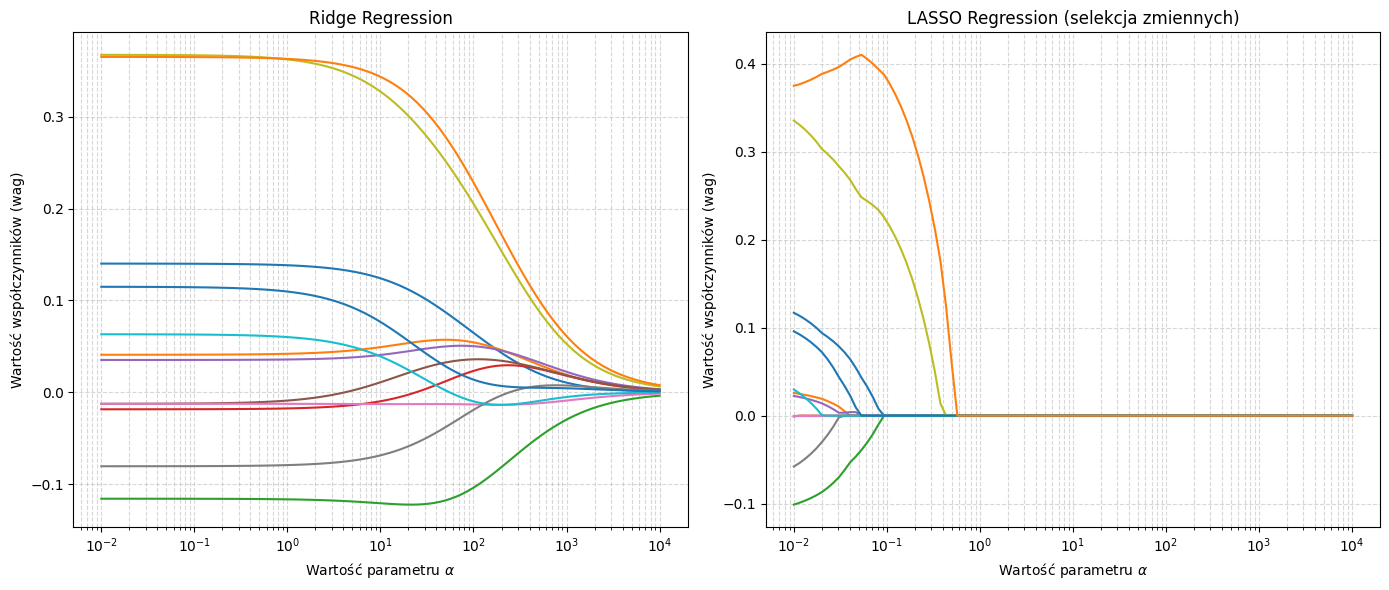

In [ ]:
ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(alphas, ridge_coefs)
axes[0].set_xscale("log")
axes[0].set_xlabel("Wartość parametru $\\alpha$")
axes[0].set_ylabel("Wartość współczynników (wag)")
axes[0].set_title("Ridge Regression")
axes[0].grid(True, which="both", ls="--", alpha=0.5)

axes[1].plot(alphas, lasso_coefs)
axes[1].set_xscale("log")
axes[1].set_xlabel("Wartość parametru $\\alpha$")
axes[1].set_ylabel("Wartość współczynników (wag)")
axes[1].set_title("LASSO Regression (selekcja zmiennych)")
axes[1].grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [77]:
ridge = ridge_pipeline_generator(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print(
    f"Ridge Test MSE: {mean_squared_error(y_test, y_pred_ridge):.2f}, Ridge Test R²: {r2_score(y_test, y_pred_ridge):.2f}"
)

lasso = lasso_pipeline_generator(alpha=1.0)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
print(
    f"LASSO Test MSE: {mean_squared_error(y_test, y_pred_lasso):.2f}, LASSO Test R²: {r2_score(y_test, y_pred_lasso):.2f}"
)

Ridge Test MSE: 0.15, Ridge Test R²: 0.64
LASSO Test MSE: 0.42, LASSO Test R²: -0.03


In [78]:
ridge_grid_search = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "regressor",
            GridSearchCV(
                Ridge(),
                param_grid={"alpha": alphas},
                cv=5,
                scoring="neg_mean_squared_error",
            ),
        ),
    ]
)

lasso_grid_search = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "regressor",
            GridSearchCV(
                Lasso(),
                param_grid={"alpha": alphas},
                cv=5,
                scoring="neg_mean_squared_error",
            ),
        ),
    ]
)

ridge_grid_search.fit(X_train, y_train)
lasso_grid_search.fit(X_train, y_train)

mse_ridge = mean_squared_error(y_test, ridge_grid_search.predict(X_test))
mse_lasso = mean_squared_error(y_test, lasso_grid_search.predict(X_test))

r2_ridge = r2_score(y_test, ridge_grid_search.predict(X_test))
r2_lasso = r2_score(y_test, lasso_grid_search.predict(X_test))

best_ridge_alpha = ridge_grid_search.named_steps["regressor"].best_params_["alpha"]
best_lasso_alpha = lasso_grid_search.named_steps["regressor"].best_params_["alpha"]

print(
    f"Best Ridge alpha: {best_ridge_alpha:.4f} with MSE: {mse_ridge:.2f} and R²: {r2_ridge:.2f}"
)
print(
    f"Best Lasso alpha: {best_lasso_alpha:.4f} with MSE: {mse_lasso:.2f} and R²: {r2_lasso:.2f}"
)

Best Ridge alpha: 14.1747 with MSE: 0.14 and R²: 0.66
Best Lasso alpha: 0.0614 with MSE: 0.17 and R²: 0.59


___

In [113]:
from ucimlrepo import fetch_ucirepo

polish_companies_bankruptcy = fetch_ucirepo(id=365)

X = polish_companies_bankruptcy.data.features
y = polish_companies_bankruptcy.data.targets

In [114]:
mask = X["year"] == 4
X = X[mask].drop(columns=["year"])
y = y[mask].iloc[:, 0]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [116]:
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, k=1.5):
        self.k = k

    def fit(self, X, y=None):
        X = np.array(X)
        Q1 = np.nanpercentile(X, 25, axis=0)
        Q3 = np.nanpercentile(X, 75, axis=0)
        IQR = Q3 - Q1
        self.lower_ = Q1 - self.k * IQR
        self.upper_ = Q3 + self.k * IQR
        return self

    def transform(self, X, y=None):
        X = np.array(X, dtype=float)
        return np.clip(X, self.lower_, self.upper_)

In [117]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [118]:
pipeline = Pipeline(
    [
        ("median_imputer", SimpleImputer(strategy="median")),
        ("iqr_clipper", IQRClipper(k=1.5)),
        ("scaler", StandardScaler()),
        ("regressor", LogisticRegression()),
    ]
)

In [124]:
def evaluate_classification(y_true, y_pred):
    
    matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    print(classification_report(y_true, y_pred))

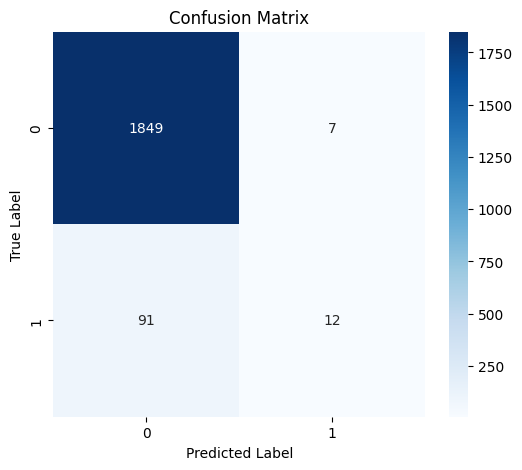

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1856
           1       0.63      0.12      0.20       103

    accuracy                           0.95      1959
   macro avg       0.79      0.56      0.59      1959
weighted avg       0.94      0.95      0.93      1959



In [125]:
model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluate_classification(y_test, y_pred)


In [128]:
ridge_pipeline_generator = lambda alpha: Pipeline(
    [
        ("median_imputer", SimpleImputer(strategy="median")),
        ("iqr_clipper", IQRClipper(k=1.5)),
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(C=1 / alpha, l1_ratio=0.0, solver="saga", max_iter=5000),
        ),
    ]
)

lasso_pipeline_generator = lambda alpha: Pipeline(
    [
        ("median_imputer", SimpleImputer(strategy="median")),
        ("iqr_clipper", IQRClipper(k=1.5)),
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(C=1 / alpha, l1_ratio=1.0, solver="saga", max_iter=5000),
        ),
    ]
)

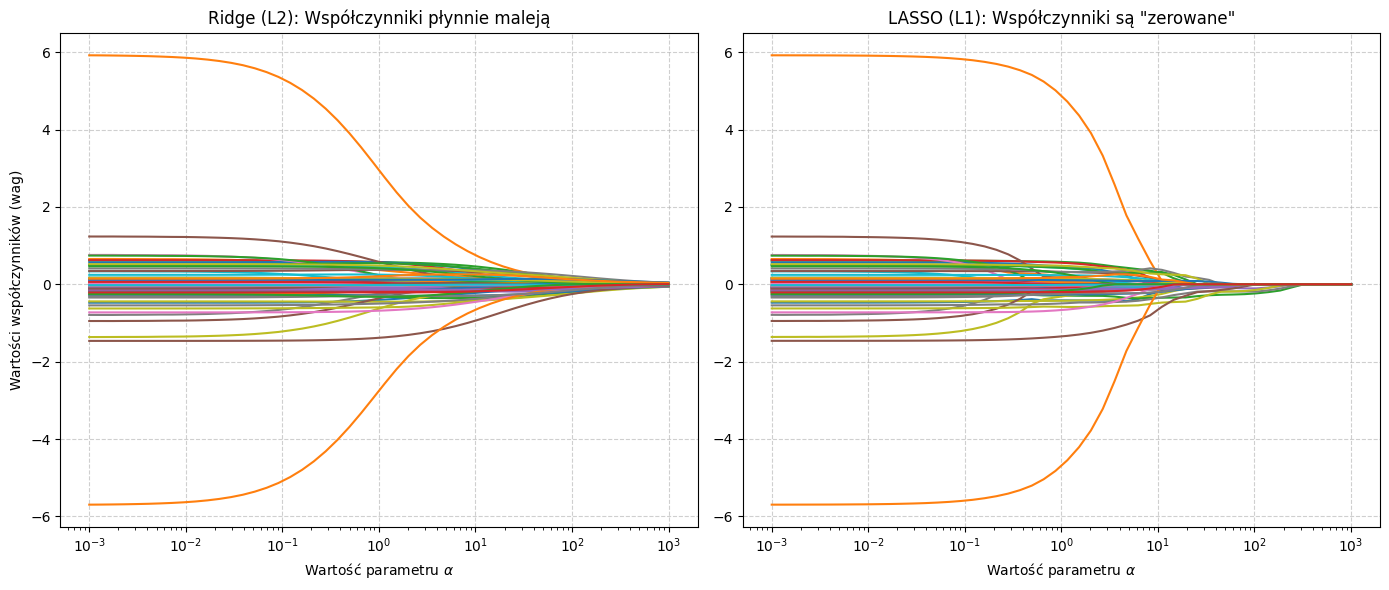

In [129]:
alphas = np.logspace(-3, 3, 50)

ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    model_r = ridge_pipeline_generator(alpha).fit(X_train, y_train)
    ridge_coefs.append(model_r.named_steps['classifier'].coef_[0])
    
    model_l = lasso_pipeline_generator(alpha).fit(X_train, y_train)
    lasso_coefs.append(model_l.named_steps['classifier'].coef_[0])

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(alphas, ridge_coefs)
axes[0].set_xscale('log')
axes[0].set_xlabel('Wartość parametru $\\alpha$')
axes[0].set_ylabel('Wartości współczynników (wag)')
axes[0].set_title('Ridge (L2): Współczynniki płynnie maleją')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(alphas, lasso_coefs)
axes[1].set_xscale('log')
axes[1].set_xlabel('Wartość parametru $\\alpha$')
axes[1].set_title('LASSO (L1): Współczynniki są "zerowane"')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best regularization: L2
Best alpha: 0.016768 (C=59.636233)
Best CV recall_macro: 0.5477


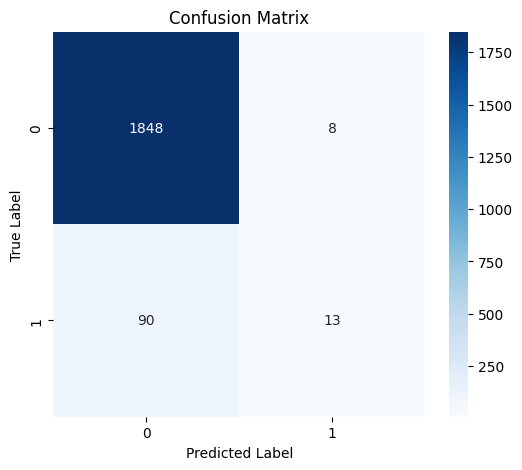

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1856
           1       0.62      0.13      0.21       103

    accuracy                           0.95      1959
   macro avg       0.79      0.56      0.59      1959
weighted avg       0.94      0.95      0.93      1959



In [132]:
alphas = np.logspace(-3, 3, 50)
c_values = 1 / alphas

logreg_pipeline = Pipeline(
    [
        ("median_imputer", SimpleImputer(strategy="median")),
        ("iqr_clipper", IQRClipper(k=1.5)),
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(solver="saga", max_iter=5000, random_state=42),
        ),
    ]
)

param_grid = {
    "classifier__l1_ratio": [0.0, 1.0],
    "classifier__C": c_values,
}

logreg_grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="recall_macro",
    n_jobs=-1,
    verbose=1,
)

logreg_grid.fit(X_train, y_train)

best_c = logreg_grid.best_params_["classifier__C"]
best_alpha = 1 / best_c
best_l1_ratio = logreg_grid.best_params_["classifier__l1_ratio"]
best_reg = "L1" if best_l1_ratio == 1.0 else "L2"

print(f"Best regularization: {best_reg}")
print(f"Best alpha: {best_alpha:.6f} (C={best_c:.6f})")
print(f"Best CV recall_macro: {logreg_grid.best_score_:.4f}")

y_pred_grid = logreg_grid.predict(X_test)
evaluate_classification(y_test, y_pred_grid)